# 第20篇｜最常用的 5 种图表：柱/折/饼/散/面积

> 这是「数据分析从入门到精通」系列的第 20 篇。画布搭好了，这篇来聊最常用的 5 种图表——柱状图、折线图、饼图、散点图、面积图。工作里 90% 的可视化需求，这 5 种就够了。

---

嗨，我是小荷～

上一篇我们学了 Matplotlib 的底层逻辑，今天来学**最常用的 5 种图表**。

说句实在话：90% 的数据分析报告，用这 5 种图就够了。掌握了这些，你能应对绝大多数业务汇报场景。

萧何当年整理粮草账目，一定也懂得"不同信息用不同呈现方式"——毕竟"总量对比"和"趋势变化"是完全不同的东西。

---

## 选图原则：什么数据用什么图？

| 图表类型 | 适合场景 | 典型问题 |
|---------|---------|---------|
| 柱状图 | 分类对比 | 各品类销售额哪个最高？ |
| 折线图 | 趋势变化 | 销售额这半年是涨是跌？ |
| 饼图 | 占比构成 | 各渠道的流量占比是多少？ |
| 散点图 | 相关关系 | 广告投入和销售额有关系吗？ |
| 面积图 | 趋势+量感 | 各品类随时间的累计贡献 |

---

## 一、柱状图（Bar Chart）

### 基础柱状图

柱状图是最常用的对比图表，先来画一个：


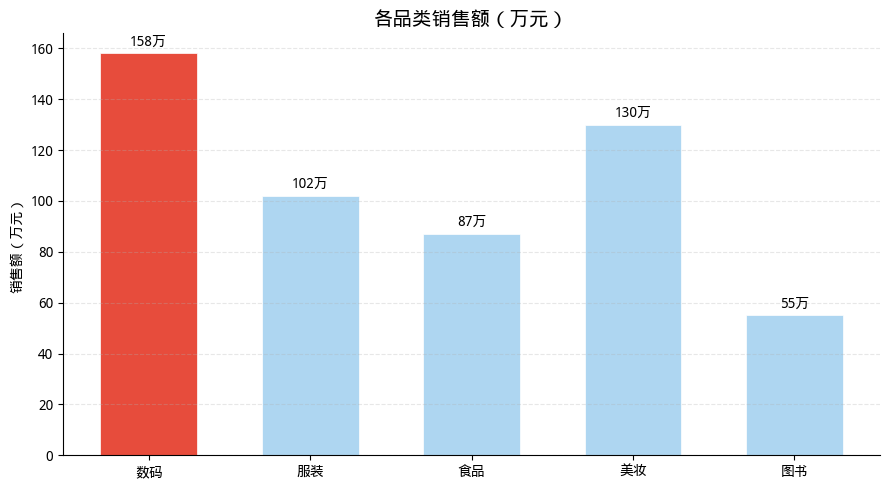

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

categories = ['数码', '服装', '食品', '美妆', '图书']
sales      = [158, 102, 87, 130, 55]
colors     = ['#E74C3C' if v == max(sales) else '#AED6F1' for v in sales]  # 最高值高亮

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(categories, sales, color=colors, width=0.6, edgecolor='white', linewidth=0.5)

# 在柱子上方标注数值
for bar, val in zip(bars, sales):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val}万', ha='center', va='bottom', fontsize=10)

ax.set_title('各品类销售额（万元）', fontsize=14, fontweight='bold')
ax.set_ylabel('销售额（万元）')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


### 分组柱状图

柱状图是最常用的对比图表，先来画一个：


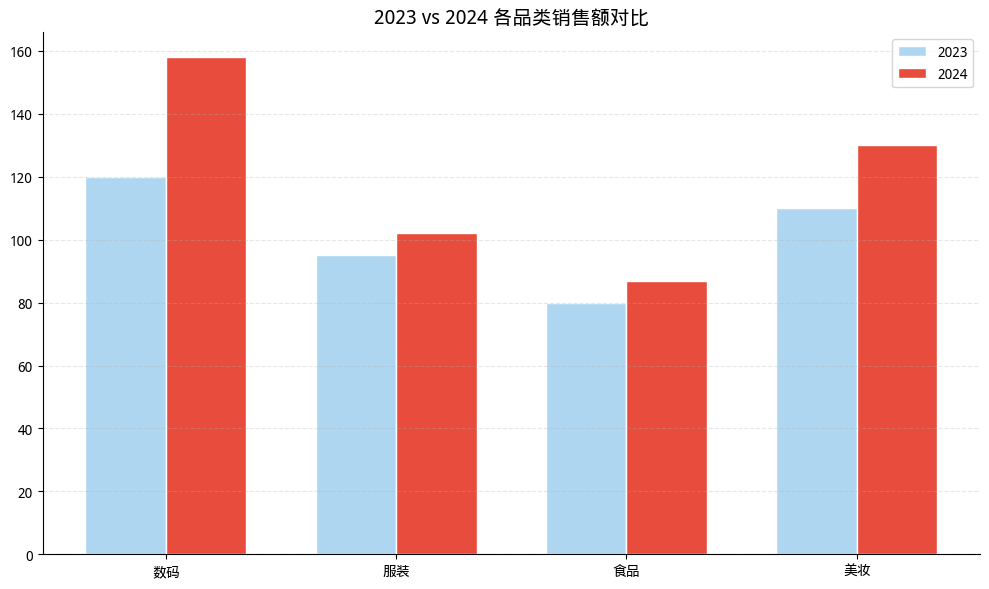

In [2]:
# 对比两年数据
categories = ['数码', '服装', '食品', '美妆']
sales_2023 = [120, 95, 80, 110]
sales_2024 = [158, 102, 87, 130]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, sales_2023, width, label='2023', color='#AED6F1', edgecolor='white')
bars2 = ax.bar(x + width/2, sales_2024, width, label='2024', color='#E74C3C', edgecolor='white')

ax.set_title('2023 vs 2024 各品类销售额对比', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


### 水平柱状图（适合类别名称长时）

柱状图是最常用的对比图表，先来画一个：


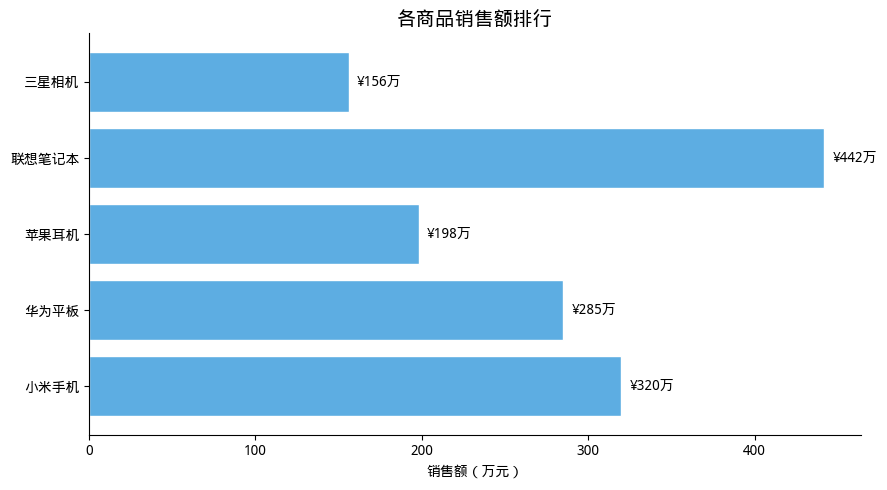

In [3]:
products = ['小米手机', '华为平板', '苹果耳机', '联想笔记本', '三星相机']
revenue  = [320, 285, 198, 442, 156]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(products, revenue, color='#5DADE2', edgecolor='white')

for bar, val in zip(bars, revenue):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'¥{val}万', va='center', fontsize=10)

ax.set_title('各商品销售额排行', fontsize=14, fontweight='bold')
ax.set_xlabel('销售额（万元）')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


---

## 二、折线图（Line Chart）

折线图擅长展示趋势变化，来画一个：


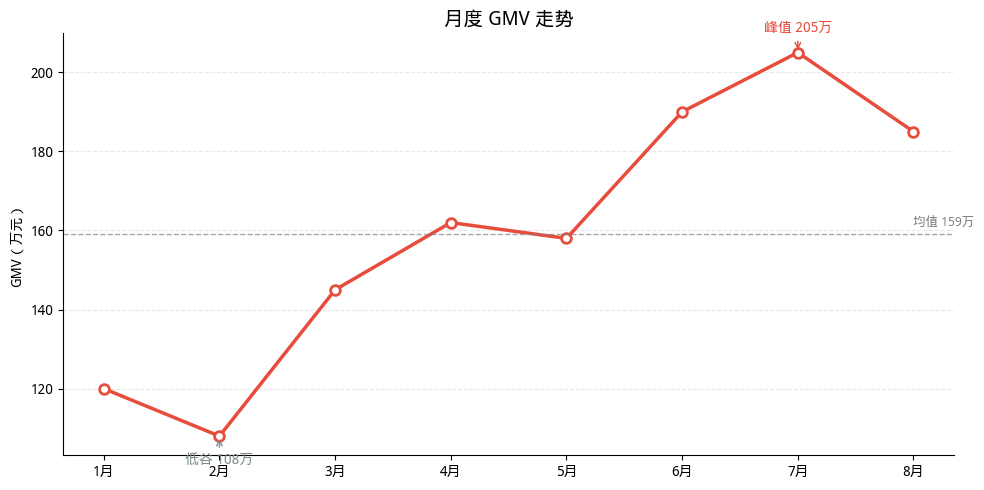

In [4]:
months = ['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月']
gmv    = [120, 108, 145, 162, 158, 190, 205, 185]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(months, gmv, marker='o', linewidth=2.5, color='#E74C3C',
        markersize=7, markerfacecolor='white', markeredgewidth=2)

# 标注最高点和最低点
max_idx = gmv.index(max(gmv))
min_idx = gmv.index(min(gmv))

ax.annotate(f'峰值 {max(gmv)}万', xy=(months[max_idx], gmv[max_idx]),
             xytext=(0, 15), textcoords='offset points',
             ha='center', color='#E74C3C', fontsize=10, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#E74C3C'))

ax.annotate(f'低谷 {min(gmv)}万', xy=(months[min_idx], gmv[min_idx]),
             xytext=(0, -20), textcoords='offset points',
             ha='center', color='#7F8C8D', fontsize=10,
             arrowprops=dict(arrowstyle='->', color='#7F8C8D'))

# 参考线
avg = np.mean(gmv)
ax.axhline(y=avg, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(months[-1], avg + 2, f'均值 {avg:.0f}万', color='gray', fontsize=9)

ax.set_title('月度 GMV 走势', fontsize=14, fontweight='bold')
ax.set_ylabel('GMV（万元）')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


---

## 三、饼图（Pie Chart）

饼图适合展示比例构成，来试试：


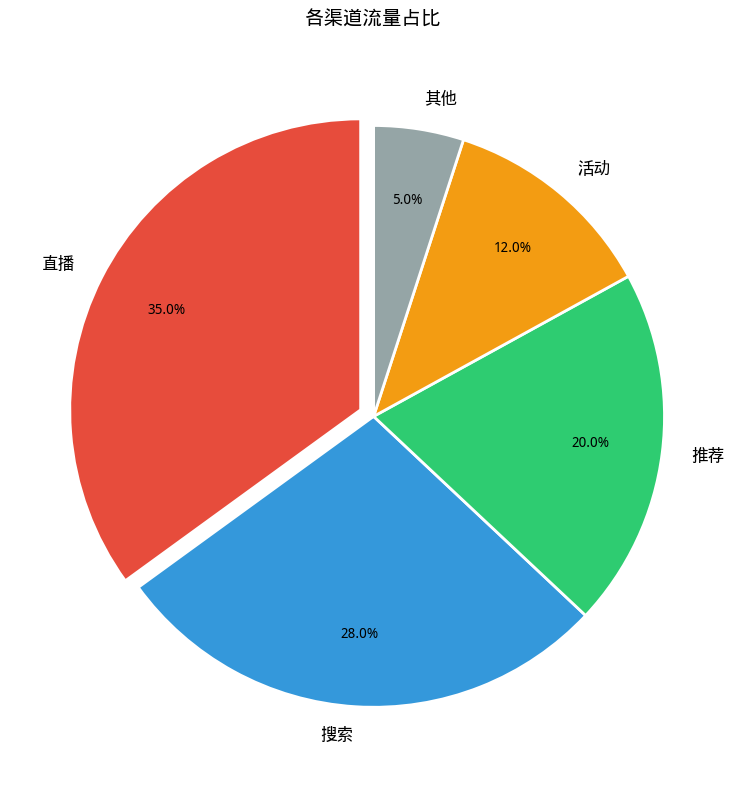

In [5]:
channels = ['直播', '搜索', '推荐', '活动', '其他']
ratios   = [35, 28, 20, 12, 5]
colors   = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#95A5A6']
explode  = [0.05, 0, 0, 0, 0]  # 第一个扇区稍微突出

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    ratios, labels=channels, autopct='%1.1f%%',
    colors=colors, explode=explode,
    startangle=90,         # 从顶部开始
    pctdistance=0.75,      # 百分比文字位置
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

# 美化字体
for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('各渠道流量占比', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


> ⚠️ **饼图使用注意**：
> - 分类不超过 6 个，太多会让人眼花缭乱
> - 占比相近的类别不适合用饼图，改用柱状图更清晰
> - 强调占比时用饼图，强调对比时用柱状图

---

## 四、散点图（Scatter Chart）

散点图用于展示两个变量的关系，来画一个：


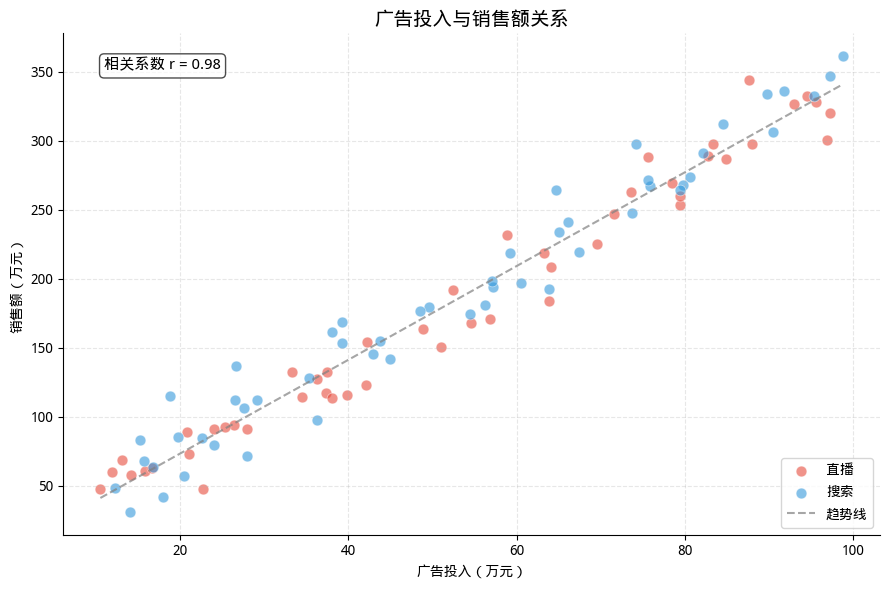

In [6]:
np.random.seed(42)
n = 100
ad_spend = np.random.uniform(10, 100, n)   # 广告投入（万元）
sales    = ad_spend * 3.5 + np.random.normal(0, 20, n)  # 销售额（万元）
# 区分两类：直播渠道 vs 搜索渠道
channel  = np.random.choice(['直播', '搜索'], n)

fig, ax = plt.subplots(figsize=(9, 6))

for ch, color in [('直播', '#E74C3C'), ('搜索', '#3498DB')]:
    mask = channel == ch
    ax.scatter(ad_spend[mask], sales[mask],
               color=color, alpha=0.6, s=60, label=ch, edgecolors='white', linewidth=0.5)

# 添加趋势线
z = np.polyfit(ad_spend, sales, 1)
p = np.poly1d(z)
x_line = np.linspace(ad_spend.min(), ad_spend.max(), 100)
ax.plot(x_line, p(x_line), color='gray', linewidth=1.5, linestyle='--', alpha=0.7, label='趋势线')

# 计算相关系数
corr = np.corrcoef(ad_spend, sales)[0, 1]
ax.text(0.05, 0.95, f'相关系数 r = {corr:.2f}', transform=ax.transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_title('广告投入与销售额关系', fontsize=14, fontweight='bold')
ax.set_xlabel('广告投入（万元）')
ax.set_ylabel('销售额（万元）')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


---

## 五、面积图（Area Chart）

面积图是折线图的"填充版"，看效果：


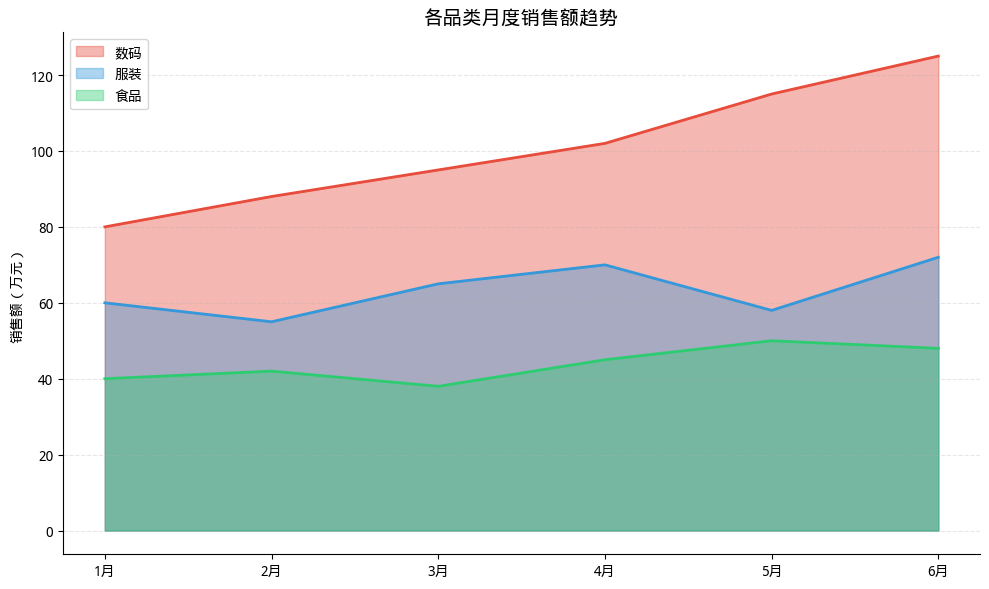

In [7]:
months = ['1月', '2月', '3月', '4月', '5月', '6月']
digital  = [80, 88, 95, 102, 115, 125]
clothing = [60, 55, 65, 70, 58, 72]
food     = [40, 42, 38, 45, 50, 48]

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(months, digital,  alpha=0.4, color='#E74C3C', label='数码')
ax.fill_between(months, clothing, alpha=0.4, color='#3498DB', label='服装')
ax.fill_between(months, food,     alpha=0.4, color='#2ECC71', label='食品')

ax.plot(months, digital,  color='#E74C3C', linewidth=2)
ax.plot(months, clothing, color='#3498DB', linewidth=2)
ax.plot(months, food,     color='#2ECC71', linewidth=2)

ax.set_title('各品类月度销售额趋势', fontsize=14, fontweight='bold')
ax.set_ylabel('销售额（万元）')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


---

## 六、📋 选图速查

| 场景 | 推荐图 | 注意事项 |
|------|--------|---------|
| A 比 B 大多少 | 柱状图 | 类别 ≤10 个效果最好 |
| 名字太长不好显示 | 水平柱状图 | — |
| 时间趋势 | 折线图 | 数据点之间有连续性 |
| 占比构成 | 饼图 | 分类 ≤6 |
| 两变量关系 | 散点图 | 加趋势线 + 相关系数更清晰 |
| 趋势 + 量感 | 面积图 | 适合强调"大小"而非精确值 |

---

## 七、📝 小结

学图表不是背代码，是**理解"什么数据用什么图"**。每次画图前先问自己：

- 我想表达**对比**、**趋势**、**占比**还是**关系**？
- 答案决定你选哪种图。

---

## 八、🏋️ 课后练习

用你在第18篇实战里得到的数据，分别画：
1. 各城市销售额——柱状图
2. 月度 GMV 趋势——折线图
3. 各品类订单占比——饼图

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# seaborn 主题会覆盖字体设置，重新指定中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ============================
# 构造模拟电商数据
# ============================

np.random.seed(42)

# 5个城市
cities = ['北京', '上海', '广州', '深圳', '杭州']

# 12个月
months = [f'{i}月' for i in range(1, 13)]

# 4个品类
categories = ['数码', '服装', '食品', '家居']

# 各城市基础销售额（万元）
city_base_sales = {'北京': 850, '上海': 920, '广州': 680, '深圳': 780, '杭州': 550}

# 各品类基础销售额（万元）
category_base_sales = {'数码': 1200, '服装': 1500, '食品': 900, '家居': 650}

# 构造城市销售数据
city_sales = {}
for city in cities:
    city_sales[city] = city_base_sales[city] + np.random.randint(-100, 150, 1)[0]

# 构造月度GMV数据（12个月）
monthly_gmv = []
base_gmv = 5000
for month in range(12):
    # 添加季节性波动（年末高）
    seasonal = 1 + 0.3 * np.sin((month - 2) * np.pi / 6)
    gmv = base_gmv * seasonal + np.random.randint(-200, 300)
    monthly_gmv.append(max(2000, gmv))

# 构造各品类订单占比
category_orders = [35, 28, 22, 15]  # 数码35%, 服装28%, 食品22%, 家居15%

print("=" * 60)
print("模拟电商数据已构造完成")
print("=" * 60)
print(f"\n城市销售数据（万元）:")
for city, sales in city_sales.items():
    print(f"  {city}: {sales}")
print(f"\n月度GMV数据（万元）:")
for i, gmv in enumerate(monthly_gmv):
    print(f"  {months[i]}: {gmv:.0f}")
print(f"\n品类订单占比: {dict(zip(categories, category_orders))}")


模拟电商数据已构造完成

城市销售数据（万元）:
  北京: 852
  上海: 999
  广州: 672
  深圳: 694
  杭州: 556

月度GMV数据（万元）:
  1月: 3572
  2月: 4238
  3月: 4820
  4月: 5652
  5月: 6220
  6月: 6766
  7月: 6313
  8月: 5880
  9月: 5258
  10月: 4137
  11月: 3873
  12月: 3399

品类订单占比: {'数码': 35, '服装': 28, '食品': 22, '家居': 15}


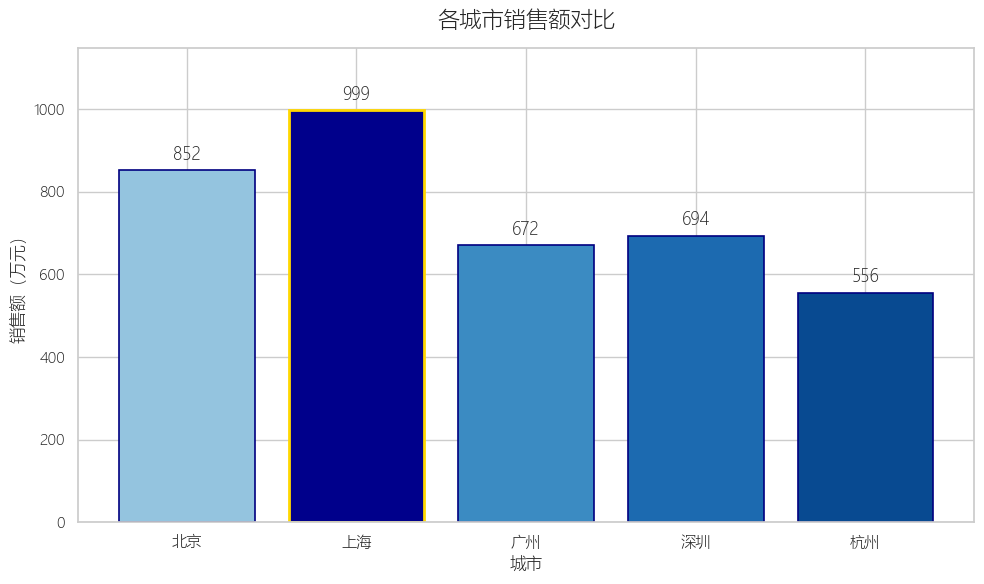

In [2]:
# ============================
# 练习1: 各城市销售额 - 柱状图
# ============================

fig1, ax1 = plt.subplots(figsize=(10, 6))

city_names = list(city_sales.keys())
sales_values = list(city_sales.values())

# 使用渐变色
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(city_names)))

bars = ax1.bar(city_names, sales_values, color=colors, edgecolor='navy', linewidth=1.2)

# 添加数值标签
for bar, value in zip(bars, sales_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f'{value}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_title('各城市销售额对比', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('城市', fontsize=12)
ax1.set_ylabel('销售额（万元）', fontsize=12)
ax1.set_ylim(0, max(sales_values) * 1.15)

# 突出最高城市
max_idx = sales_values.index(max(sales_values))
bars[max_idx].set_color('darkblue')
bars[max_idx].set_edgecolor('gold')
bars[max_idx].set_linewidth(2)

plt.tight_layout()
plt.show()

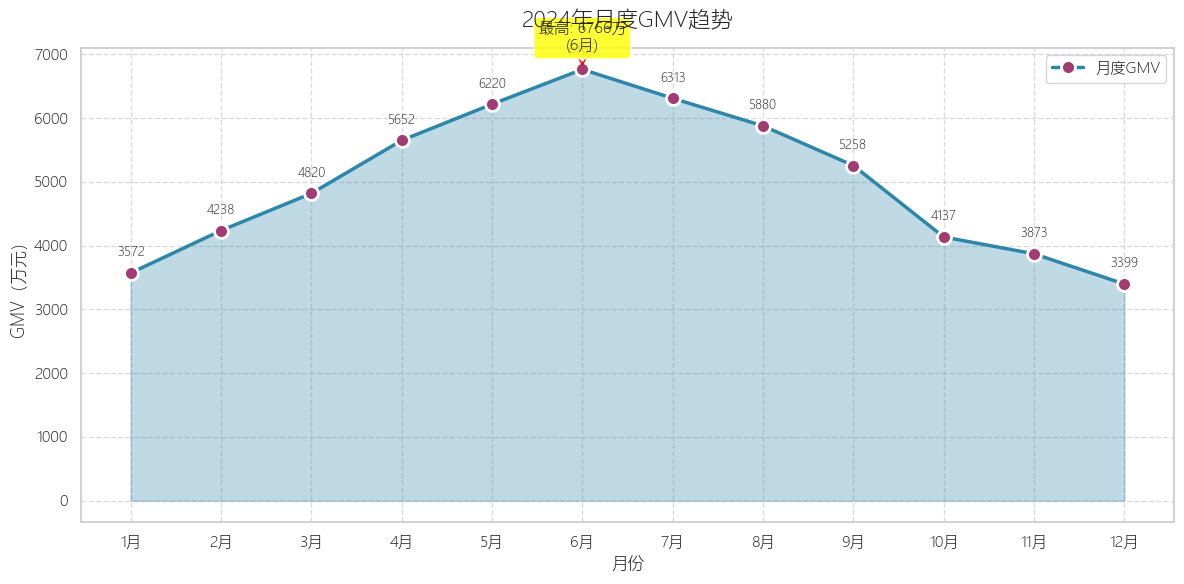

In [3]:
# ============================
# 练习2: 月度GMV趋势 - 折线图
# ============================

fig2, ax2 = plt.subplots(figsize=(12, 6))

# 主折线
ax2.plot(months, monthly_gmv, marker='o', markersize=10, linewidth=2.5,
         color='#2E86AB', label='月度GMV', markerfacecolor='#A23B72',
         markeredgecolor='white', markeredgewidth=2)

# 填充区域
ax2.fill_between(months, monthly_gmv, alpha=0.3, color='#2E86AB')

# 添加数值标签
for i, gmv in enumerate(monthly_gmv):
    ax2.annotate(f'{gmv:.0f}', (months[i], gmv),
                 textcoords="offset points", xytext=(0, 12),
                 ha='center', fontsize=9, fontweight='bold')

ax2.set_title('2024年月度GMV趋势', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('月份', fontsize=12)
ax2.set_ylabel('GMV（万元）', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)

# 标注最高点
max_gmv_idx = monthly_gmv.index(max(monthly_gmv))
ax2.annotate(f'最高: {max(monthly_gmv):.0f}万\n({months[max_gmv_idx]})',
             xy=(months[max_gmv_idx], max(monthly_gmv)),
             xytext=(months[max_gmv_idx], max(monthly_gmv) + 300),
             fontsize=11, ha='center',
             arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

plt.tight_layout()
plt.show()

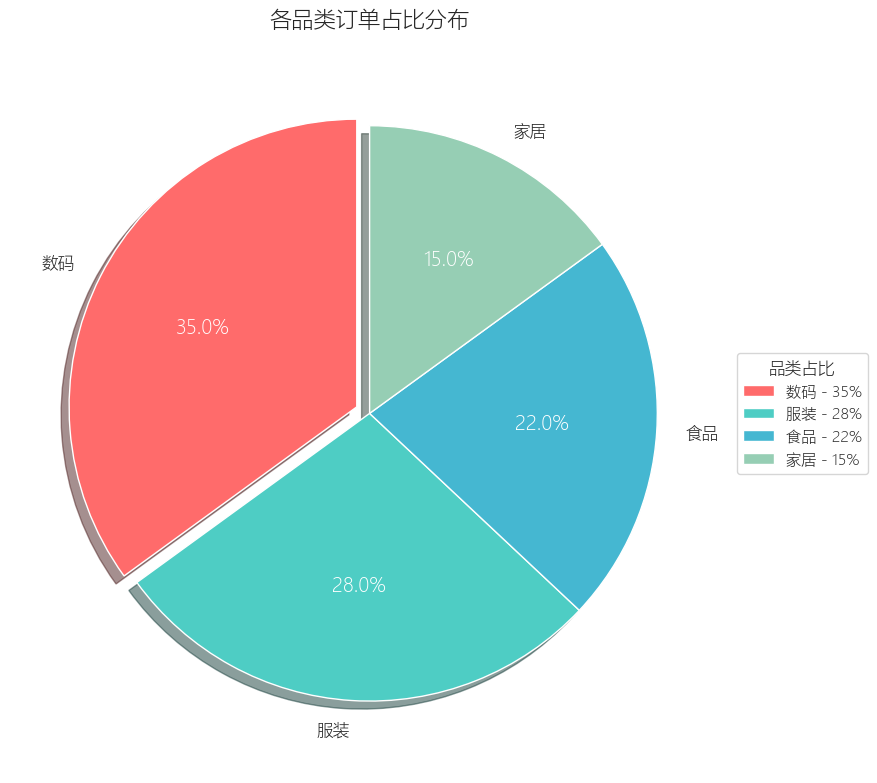

In [4]:

# ============================
# 练习3: 各品类订单占比 - 饼图
# ============================

fig3, ax3 = plt.subplots(figsize=(10, 8))

# 设置颜色
pie_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# 突出最大扇形
explode = [0.05 if c == max(category_orders) else 0 for c in category_orders]

wedges, texts, autotexts = ax3.pie(category_orders, labels=categories,
                                     autopct='%1.1f%%', startangle=90,
                                     colors=pie_colors, explode=explode,
                                     shadow=True, textprops={'fontsize': 12})

# 设置百分比文字样式
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

# 添加图例
ax3.legend(wedges, [f'{c} - {p}%' for c, p in zip(categories, category_orders)],
           title="品类占比", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=11)

ax3.set_title('各品类订单占比分布', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 21 篇：图表美化 — 颜色 / 字体 / 注释 / 样式**
>
> 会画图了，怎么把图画得更好看？下篇来学图表美化，把默认风格升级成杂志级效果。

---

*跟着小荷，数据分析路上不迷路～*